# Click Propensity and Ranking — phase two

Assess ad-context ranking, probability reliability, and error patterns under explicit sampling limits.

The documented OpenML/Tencent benchmark is retained and deduplicated to 39,926 contexts. User/context groups remain disjoint across all four partitions. The negatives were downsampled upstream, so all score scales and observed click rates refer to the benchmark.

This notebook executes the same standalone implementation; original notebooks are preserved.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, Markdown
from phase2 import run
summary = run()
summary

ctr: selected logistic_regression; AP=0.2850; log loss=0.4411; elapsed=7.4s


{'project': 'ctr',
 'input_file': 'clicks.csv',
 'input_sha256': 'a31e7ed1237d1d78ae0556e986b583360effdf2c8b5d67a009410be82ec73043',
 'rows_read': 39948,
 'rows_used': 39926,
 'duplicates_removed': 22,
 'split_strategy': 'grouped 60/20/20; known users and identical anonymous contexts never cross partitions',
 'excluded_features': ['impression',
  'user_id',
  'url_hash',
  'click',
  'clicked',
  'click_time',
  'view_count'],
 'benchmark_warning': 'Majority class was downsampled upstream; click scores are not population CTR estimates.',
 'selected_model': 'logistic_regression',
 'threshold': 0.18113232691012277,
 'selection': 'validation log loss',
 'protocol': 'fit 45%, independent sigmoid calibration 15%, validation 20%, test 20%; grouped or chronological where available',
 'splits': {'fit': {'rows': 17964, 'positives': 3000},
  'calibration': {'rows': 5993, 'positives': 1046},
  'validation': {'rows': 7985, 'positives': 1288},
  'test': {'rows': 7984, 'positives': 1391}},
 'test': 

In [2]:
display(pd.read_csv('results/phase2/metrics.csv'))

,model,split,average_precision,roc_auc,log_loss,brier_score,accuracy,precision,recall,f1,threshold,tn,fp,fn,tp,alerts,positive_rate,rows
0,baseline,validation,0.161302,0.500000,0.441941,0.135316,0.838698,0.000000,0.000000,0.000000,0.500000,6697,0,1288,0,0,0.161302,7985
1,logistic_regression,validation,0.273886,0.639655,0.420526,0.129143,0.639950,0.233993,0.541925,0.326856,0.181132,4412,2285,590,698,2983,0.161302,7985
2,logistic_regression_sigmoid,validation,0.273886,0.639655,0.420854,0.129225,0.639950,0.233993,0.541925,0.326856,0.190354,4412,2285,590,698,2983,0.161302,7985
3,random_forest,validation,0.260275,0.639918,0.428667,0.131482,0.668754,0.244829,0.505435,0.329871,0.174828,4689,2008,637,651,2659,0.161302,7985
4,random_forest_sigmoid,validation,0.260275,0.639918,0.430261,0.131476,0.668754,0.244829,0.505435,0.329871,0.184645,4689,2008,637,651,2659,0.161302,7985
5,baseline,test,0.174223,0.500000,0.462706,0.143922,0.825777,0.000000,0.000000,0.000000,0.500000,6593,0,1391,0,0,0.174223,7984
6,logistic_regression,test,0.285040,0.643960,0.441080,0.137481,0.634269,0.253148,0.563623,0.349376,0.181132,4280,2313,607,784,3097,0.174223,7984
7,logistic_regression_sigmoid,test,0.285040,0.643960,0.440646,0.137365,0.634269,0.253148,0.563623,0.349376,0.190354,4280,2313,607,784,3097,0.174223,7984
8,random_forest,test,0.282129,0.645592,0.449462,0.140066,0.667084,0.264760,0.512581,0.349167,0.174828,4613,1980,678,713,2693,0.174223,7984
9,random_forest_sigmoid,test,0.282129,0.645592,0.449599,0.139498,0.667084,0.264760,0.512581,0.349167,0.184645,4613,1980,678,713,2693,0.174223,7984


In [3]:
display(Markdown(Path('results/phase2/REPORT.md').read_text()))

# Phase two: evidence and decision trade-offs

39,926 deduplicated observations. **logistic_regression** was selected using validation log loss.
fit 45%, independent sigmoid calibration 15%, validation 20%, test 20%; grouped or chronological where available. Calibration uses disjoint reserve labels; preprocessing fits only on fit rows.

| Test measure | Selected | Prior baseline |
|---|---:|---:|
| Average precision | 0.2850 | 0.1742 |
| Log loss | 0.4411 | 0.4627 |
| Brier score | 0.1375 | 0.1439 |
| Precision | 25.3% | 0.0% |
| Recall | 56.4% | 0.0% |

At the validation-selected threshold, 784 positives are found, 607 are missed, and 2313 false flags occur.
95% Wilson recall interval: 53.7%–58.9%; precision: 23.8%–26.9%.
The intervals describe this benchmark sample under the stated sampling assumptions.

![Calibration reliability and bin support](reliability.png)
![Ranking budget and captured positives](ranking.png)

[Operating policies](operating_policies.csv) choose thresholds exclusively from validation scores for fixed workload budgets.
Ties stay together and can leave a budget partly unused. Applying the same thresholds to test can exceed the validation budget;
the table records actual counts. No dollar-saving or intervention-effect claim is inferred from these retrospective labels.

[Uncertainty](uncertainty.json) contains 200 bootstrap replicates, with clusters resampled when user/context groups exist.
[Validation stability](validation_stability.csv) tests a fixed model structure on three development-only splits.
[Subgroup errors](subgroup_errors.csv) gives support and missed/false-flag counts; small groups warrant caution.
[Error rows](errors.csv), [all candidate metrics](metrics.csv), [test predictions](predictions.csv), and [partition membership](splits.csv) are auditable.

The final test labels are not used to choose calibration, models, budgets, or thresholds. Previously published benchmark results
were known during redevelopment; an independent external evaluation remains necessary. Calibration assumes the same target population.
For CTR, calibration cannot undo unknown upstream negative sampling. For HR, observation dates and a departure horizon are missing;
feature-importance consistency is association, not causality. The fraud benchmark spans two days and anonymized PCA features.


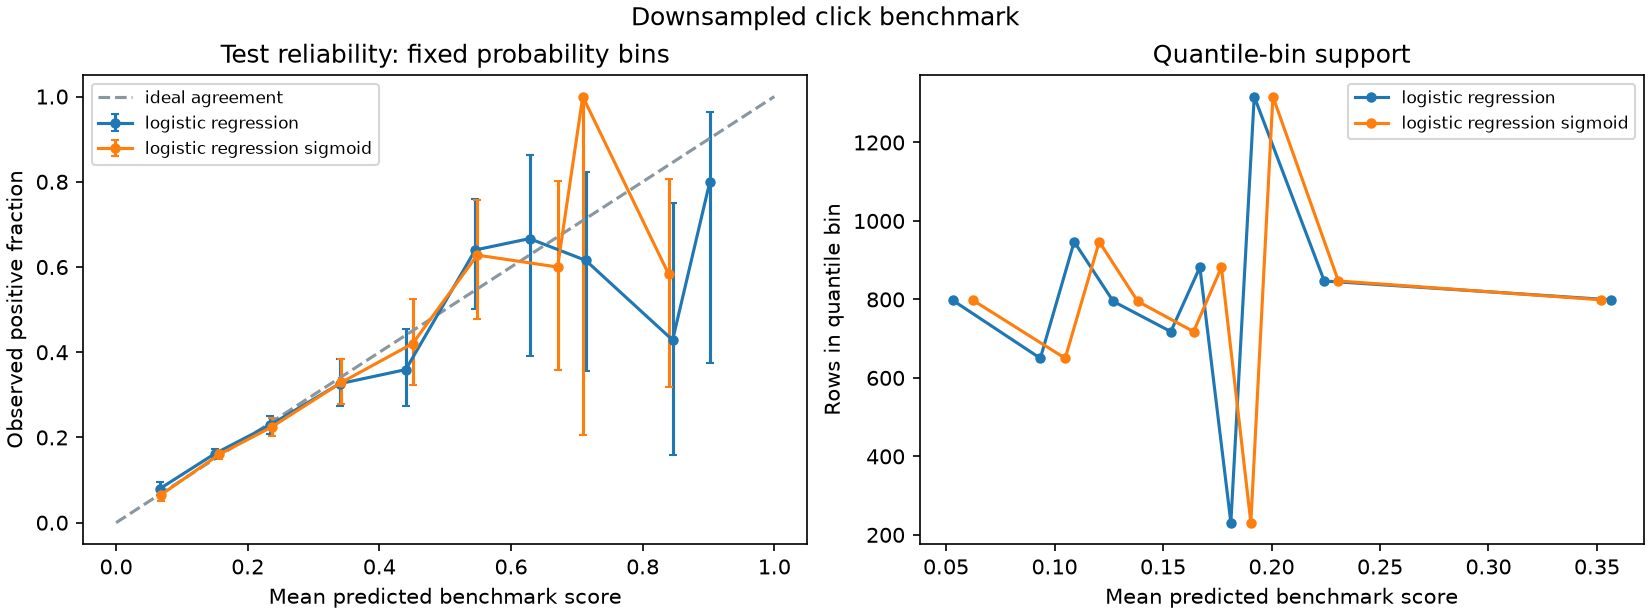

,fold,fit_rows,calibration_rows,validation_rows,average_precision,roc_auc,log_loss,brier_score,accuracy,precision,recall,f1,threshold,tn,fp,fn,tp,alerts,positive_rate,rows
0,1,17965,5984,7993,0.271514,0.639071,0.414016,0.126203,0.663456,0.235641,0.510367,0.322418,0.192566,4663,2076,614,640,2716,0.156887,7993
1,2,17964,5992,7986,0.296003,0.644769,0.435590,0.135179,0.634360,0.250242,0.562909,0.346464,0.170871,4292,2319,601,774,3093,0.172176,7986
2,3,17977,5982,7983,0.301473,0.640065,0.438937,0.136364,0.627834,0.247277,0.554200,0.341971,0.174004,4240,2350,621,772,3122,0.174496,7983


In [4]:
display(Image(filename='results/phase2/reliability.png'))
display(pd.read_csv('results/phase2/validation_stability.csv'))

In [5]:
json.loads(Path('results/phase2/uncertainty.json').read_text())

{'level': 0.95,
 'method': 'Cluster bootstrap of held-out users/anonymous contexts',
 'replicates': 200,
 'intervals': {'average_precision': {'low': 0.263934445360299,
   'high': 0.3075536821748438},
  'f1': {'low': 0.33450856167191495, 'high': 0.3636115417828573},
  'log_loss': {'low': 0.4282433459165197, 'high': 0.45398252230045494}},
 'recall_wilson': {'estimate': 0.5636232925952552,
  'low': 0.5374212721578293,
  'high': 0.5894748699669174,
  'n': 1391},
 'precision_wilson': {'estimate': 0.25314820794317083,
  'low': 0.23814668199554223,
  'high': 0.26876135561128645,
  'n': 3097},
 'limits': 'Wilson intervals assume independent rows; cluster bootstrap is used when IDs exist. Neither method establishes future-domain performance or accounts for two-day temporal dependence.'}

In [6]:
display(pd.read_csv('results/phase2/errors.csv').head(10))

,row_id,actual,selected_score,predicted,baseline_score,logistic_regression_score,logistic_regression_sigmoid_score,random_forest_score,random_forest_sigmoid_score
0,31,0,0.209106,1,0.167001,0.209106,0.216664,0.173824,0.182810
1,35,0,0.212499,1,0.167001,0.212499,0.219834,0.160253,0.159382
2,44,1,0.175448,0,0.167001,0.175448,0.184966,0.171709,0.178990
3,110,0,0.216209,1,0.167001,0.216209,0.223296,0.178185,0.190883
4,114,1,0.123652,0,0.167001,0.123652,0.135019,0.160689,0.160095
5,118,1,0.166964,0,0.167001,0.166964,0.176894,0.139473,0.128297
6,142,0,0.204606,1,0.167001,0.204606,0.212454,0.164560,0.166542
7,167,0,0.190762,1,0.167001,0.190762,0.199449,0.179860,0.194056
8,224,0,0.194228,1,0.167001,0.194228,0.202712,0.171472,0.178565
9,229,0,0.244773,1,0.167001,0.244773,0.249796,0.189599,0.213297


,validation_budget_fraction,split,average_precision,roc_auc,log_loss,brier_score,accuracy,precision,recall,f1,threshold,tn,fp,fn,tp,alerts,positive_rate,rows
0,0.001,validation,0.273886,0.639655,0.420526,0.129143,0.838698,0.000000,0.000000,0.000000,0.902000,6697,0,1288,0,0,0.161302,7985
1,0.001,test,0.285040,0.643960,0.441080,0.137481,0.825777,0.000000,0.000000,0.000000,0.902000,6593,0,1391,0,0,0.174223,7984
2,0.002,validation,0.273886,0.639655,0.420526,0.129143,0.839574,0.733333,0.008540,0.016884,0.845450,6693,4,1277,11,15,0.161302,7985
3,0.002,test,0.285040,0.643960,0.441080,0.137481,0.826027,0.583333,0.005032,0.009979,0.845450,6588,5,1384,7,12,0.174223,7984
4,0.005,validation,0.273886,0.639655,0.420526,0.129143,0.839699,0.605263,0.017857,0.034691,0.577460,6682,15,1265,23,38,0.161302,7985
5,0.005,test,0.285040,0.643960,0.441080,0.137481,0.827029,0.625000,0.017973,0.034941,0.577460,6578,15,1366,25,40,0.174223,7984
6,0.010,validation,0.273886,0.639655,0.420526,0.129143,0.839825,0.556962,0.034161,0.064375,0.519729,6662,35,1244,44,79,0.161302,7985
7,0.010,test,0.285040,0.643960,0.441080,0.137481,0.827906,0.619718,0.031632,0.060192,0.519729,6566,27,1347,44,71,0.174223,7984
8,0.050,validation,0.273886,0.639655,0.420526,0.129143,0.830557,0.418546,0.129658,0.197985,0.306298,6465,232,1121,167,399,0.161302,7985
9,0.050,test,0.285040,0.643960,0.441080,0.137481,0.815506,0.401442,0.120058,0.184837,0.306298,6344,249,1224,167,416,0.174223,7984


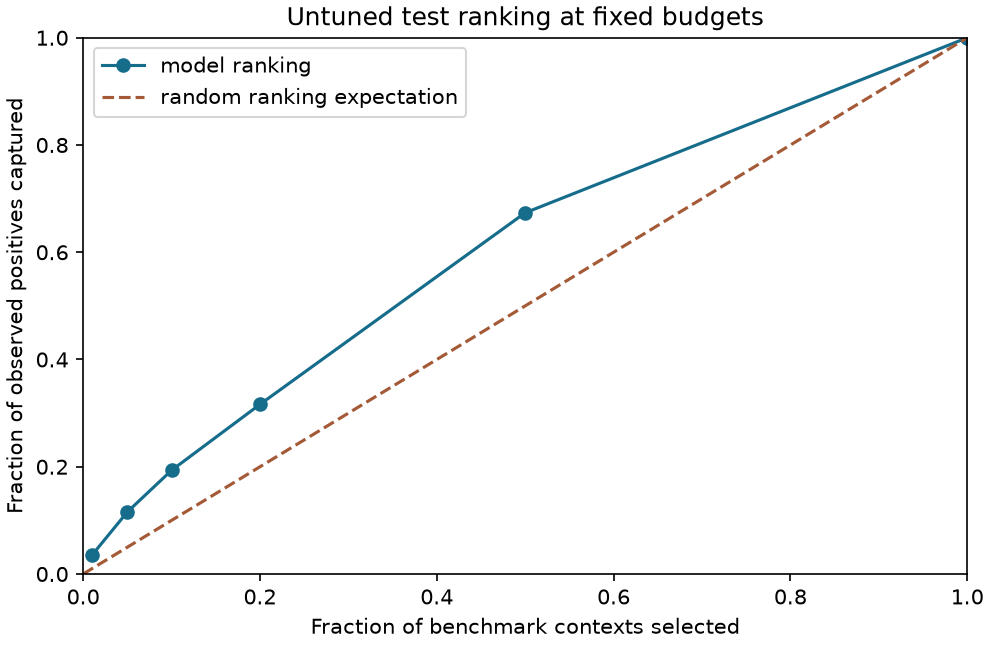

In [7]:
display(pd.read_csv('results/phase2/operating_policies.csv'))
display(Image(filename='results/phase2/ranking.png'))

## Interpretation

A calibrated model is retained only if it improves validation log loss. Cluster bootstrap resamples users/anonymous contexts. Fixed ranking budgets show positive capture and lift; validation-derived thresholds are separately tested. Depth and position error groups expose weak contexts. Three development-only group splits assess stability.

A representative temporal benchmark was investigated through Criteo’s official dataset pages. The downloadable alternatives are substantially larger, require different schemas, and do not establish the missing original campaign’s prevalence or timestamps. No bulk archive was downloaded. Population CTR and future-campaign validation require documented impression logs; calibration alone cannot reconstruct unknown sampling.